In [3]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [7]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [9]:
print(housing.DESCR) 

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [11]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [13]:
x=housing.data[:,2] ##只使用房间数量

In [15]:
x.shape

(20640,)

In [16]:
y=housing.target

In [17]:
 y.shape

(20640,)

<function matplotlib.pyplot.show(close=None, block=None)>

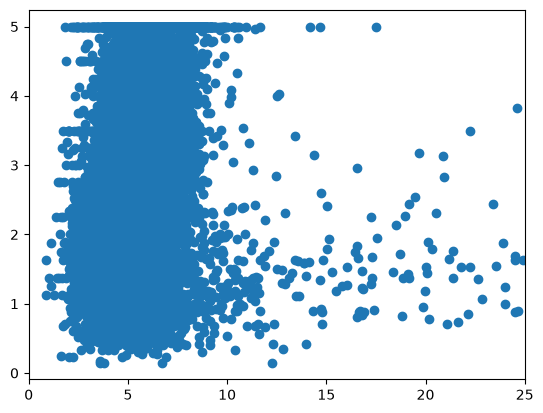

In [22]:
plt.scatter(x,y)
plt.axis=[0,50,0,5]
plt.xlim(0,25)
plt.show

In [24]:
np.max(y)

np.float64(5.00001)

In [25]:
x=x[y<5]
y=y[y<5]

<function matplotlib.pyplot.show(close=None, block=None)>

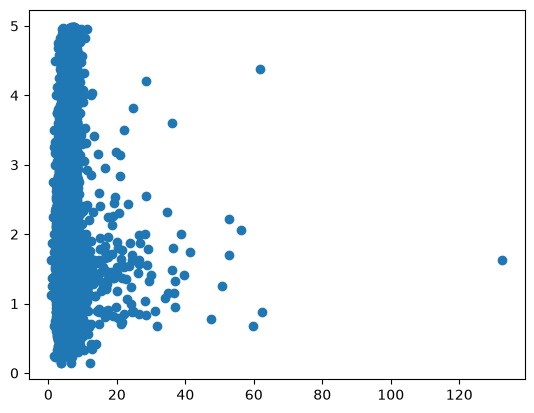

In [27]:
plt.scatter(x,y)
plt.show

In [29]:
from sklearn.model_selection import train_test_split

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [32]:
x_train.shape

(15718,)

In [33]:
x_train_mean=np.mean(x_train)
y_train_mean=np.mean(y_train)

In [35]:
num=0.0
d=0.0
for x_i,y_i in zip(x_train,y_train):
    num+=(x_i-x_train_mean)*(y_i-y_train_mean)
    d+=(x_i-x_train_mean)**2

In [36]:
a=num/d
b=y_train_mean-a*x_train_mean

In [38]:
a

np.float64(0.045205698291192586)

In [39]:
b

np.float64(1.6733224547319365)

In [40]:
y_predict=a*x_test+b

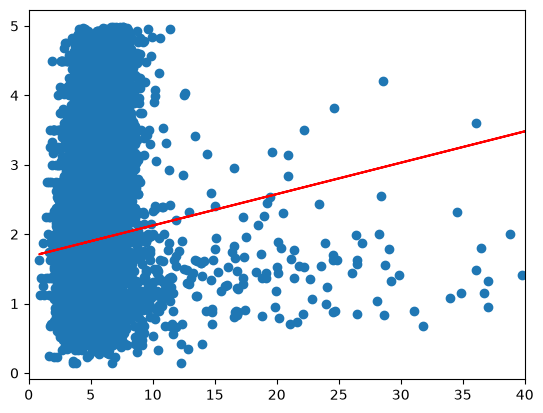

In [43]:
plt.scatter(x,y)
plt.plot(x_test,y_predict,color='r')
plt.xlim(0,40)
plt.show()

MSE

In [47]:
mse_test=np.sum((y_predict-y_test)**2)/len(y_test)
mse_test

np.float64(0.9549829445391591)

RMSE

In [49]:
from math import sqrt
rmse_test=sqrt(mse_test)
rmse_test

0.9772322879127353

MAE

In [51]:
mae_test=np.sum(np.absolute(y_predict-y_test))/len(y_test)
mae_test

np.float64(0.7774689132480939)

sklearn 中

In [56]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score

In [53]:
mean_squared_error(y_test,y_predict)

0.9549829445391591

In [54]:
mean_absolute_error(y_test,y_predict)

0.7774689132480939

In [62]:
accuracy_score(x_test,y_test)

ValueError: continuous is not supported

R-squard

In [60]:
1-mean_squared_error(y_test,y_predict)/np.var(y_test)

np.float64(0.013298030957530127)

In [61]:
from sklearn.metrics import r2_score

r2_score(y_test,y_predict)

0.013298030957530127